---
title: "Counting the Unseen in La Plata"
subtitle: "Using building footprints to repair population estimates in informal settlements"
author: "Nissim Lebovits, Juan Carlos Etulaín, and Celeste Duarte"
date: "2026-06-11"
execute:
  cache: true
  freeze: auto
---

## Introduction

Climate risk is the product of hazard, exposure, and vulnerability. The
cookbooks on [Pergamino](pergamino.ipynb) and [Esperanza](esperanza.ipynb)
lean on the hazard side. This one is about exposure, and specifically about a
population that is vulnerable almost by definition: the residents of informal
settlements.

Before you can map who is exposed to a flood or a heat wave, you need to know
where people live and how many of them there are. In informal settlements that
basic question is surprisingly hard to answer. The people who live there are,
by the nature of informal settlement, undercounted by the official record.

This cookbook shows how open **building footprints** can repair that record. We
work in the Partido de La Plata, in Buenos Aires Province, and compare the
official settlement registry against buildings detected from satellite imagery.
The lesson is not that the official data are worthless. It is that two
imperfect sources, used together, see far more than either one alone.

This is the local slice of a national study. The
[Barrios Visibles working paper](https://nlebovits.github.io/posts/writing/informal-settlements-argentina/)
[@lebovits_barrios_visibles] runs the same method across all of Argentina, and
the [barriosvisibles.org](https://www.barriosvisibles.org) dashboard lets you
inspect every settlement against a satellite basemap. We point back to those
for the full argument and the sensitivity analysis.

In [ ]:
import os
import requests
from io import BytesIO

import duckdb
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import contextily as cx

import geoparquet_io as gpio

# CRS settings
USE_CRS = "EPSG:5346"  # POSGAR 2007 / Argentina 3 (Buenos Aires)
WGS84_CRS = "EPSG:4326"
WEB_MERCATOR_CRS = "EPSG:3857"

# Visualization defaults
DEFAULT_FIGSIZE = (10, 8)
plt.rcParams["figure.dpi"] = 100


def fmt(n):
    """Format a number with thousands separators."""
    return f"{int(round(n)):,}"

## Data sources

We use three open datasets.

The **Registro Nacional de Barrios Populares (RENABAP)** is Argentina's official
registry of informal settlements [@renabap_2023]. A *barrio popular* is a
settlement of at least eight families where most residents lack secure land
tenure and regular access to at least two basic services (water, sewerage,
electricity, or gas). For each settlement RENABAP records a polygon boundary and
an approximate number of families. We use the snapshot dated 6 December 2023.

The **Google-Microsoft-OSM Open Buildings** dataset, combined by VIDA, merges
machine-learning building detections from Google and Microsoft with
OpenStreetMap footprints [@google_microsoft_osm_buildings]. It contains roughly
2.7 billion footprints worldwide and is hosted on Source Cooperative as cloud-native
GeoParquet.

The municipal boundary comes from Argentina's **Instituto Geográfico Nacional
(IGN)**, served as a Web Feature Service [@ign_municipios_2025].

::: {.callout-note}
## Sidebar: what is a building footprint?

A **building footprint** is the outline of a building's roof as seen from above,
stored as a polygon. Footprint datasets are produced by running computer-vision
models over satellite or aerial imagery. They tell you where structures are and
how large they are, but not how tall they are or how many people live inside.
That last gap is exactly why footprints supplement, rather than replace, a
household registry.
:::

## Preparing the registry

RENABAP publishes the registry as a single 6.5 MB GeoJSON file. GeoJSON is
convenient to download but slow to query: it is plain text, it stores every
coordinate as a string, and it carries no spatial index. Before we work with it
we convert it to **GeoParquet**, a columnar binary format, and optimize it with
[`geoparquet-io`](https://geoparquet.io).

The optimization does two things. `add_bbox` writes a bounding-box column so a
query engine can skip data that falls outside the area of interest. `sort_hilbert`
reorders the rows along a space-filling curve so that settlements near each other
in space sit near each other on disk. Together they turn a file you scan into a
file you query.

In [ ]:
renabap_geojson = "renabap-2023-12-06.geojson"
renabap_url = (
    "https://www.argentina.gob.ar/sites/default/files/renabap-2023-12-06.geojson"
)

if not os.path.exists(renabap_geojson):
    response = requests.get(
        renabap_url, headers={"User-Agent": "Mozilla/5.0"}, timeout=120
    )
    response.raise_for_status()
    with open(renabap_geojson, "wb") as f:
        f.write(response.content)

# Convert GeoJSON to optimized GeoParquet (bbox column + Hilbert ordering).
# GeoParquet 1.1 keeps WKB geometry, which is widely readable.
renabap_parquet = "renabap.parquet"
gpio.convert(renabap_geojson).add_bbox().sort_hilbert().write(
    renabap_parquet, geoparquet_version="1.1", overwrite=True
)

PosixPath('renabap.parquet')

## La Plata's informal settlements

We load the Partido de La Plata boundary from the IGN, then keep the RENABAP
settlements that fall inside it.

In [ ]:
# Partido de La Plata boundary from the IGN Web Feature Service
ign_wfs_url = "https://wms.ign.gob.ar/geoserver/ign/ows"
params = {
    "service": "WFS",
    "version": "2.0.0",
    "request": "GetFeature",
    "typename": "ign:departamento",
    "outputFormat": "application/json",
    "CQL_FILTER": "nam='La Plata'",
}
response = requests.get(ign_wfs_url, params=params, timeout=60)
la_plata = gpd.read_file(BytesIO(response.content)).to_crs(WGS84_CRS)

# Settlements intersecting La Plata
renabap = gpd.read_parquet(renabap_parquet)
if renabap.crs is None:
    renabap = renabap.set_crs(WGS84_CRS)
renabap = renabap.to_crs(WGS84_CRS)

barrios = (
    gpd.sjoin(renabap, la_plata[["geometry"]], predicate="intersects")
    .drop_duplicates("id_renabap")
    .drop(columns="index_right")
)

n_barrios = len(barrios)
renabap_families = int(barrios["familias_aproximadas"].sum())
print(f"Settlements in La Plata: {n_barrios}")
print(f"RENABAP families: {renabap_families:,}")

Settlements in La Plata: 168
RENABAP families: 34,044


RENABAP records 168 settlements in the Partido de La Plata, holding about
34,000 families (the code cell above prints the exact counts). Those numbers
come from field surveys, but the family counts lean heavily on projections
from the 2010 national census. In settlements that grow quickly and
informally, a count anchored to 2010 ages badly.

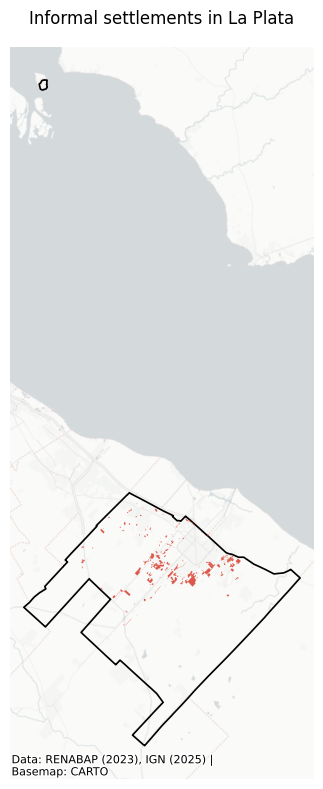

In [ ]:
# | label: fig-barrios
# | fig-cap: "RENABAP informal settlements in the Partido de La Plata"
# | code-fold: true
# | code-summary: "Show plot code"

fig, ax = plt.subplots(figsize=DEFAULT_FIGSIZE)
la_plata.to_crs(WEB_MERCATOR_CRS).plot(
    ax=ax, facecolor="none", edgecolor="black", linewidth=1.2
)
barrios.to_crs(WEB_MERCATOR_CRS).plot(
    ax=ax, facecolor="#d7301f", edgecolor="none", alpha=0.8
)
cx.add_basemap(
    ax,
    crs=WEB_MERCATOR_CRS,
    source=cx.providers.CartoDB.PositronNoLabels,
    attribution="Data: RENABAP (2023), IGN (2025) | Basemap: CARTO",
)
ax.set_title("Informal settlements in La Plata")
ax.axis("off")
plt.tight_layout()
plt.show()

## Bringing in building footprints

Now the supplement. We pull every building footprint in the La Plata area from
the VIDA dataset on Source Cooperative.

The VIDA file is national, over four gigabytes, and stored on remote object
storage. We do not want all of it, only the buildings near La Plata, so we use
DuckDB to filter by bounding box at the source and download just that subset.

::: {.callout-important}
## Download, optimize, then query

The remote VIDA file is not spatially optimized: its rows are not ordered in
space, so a bounding-box filter still has to scan most of the file. That one
remote query is slow. The fix is to pull the subset down once, optimize it
locally with `geoparquet-io`, and run all further work against the local file.
A spatial query that took over a minute against the remote file runs in a few
seconds against the optimized local copy.
:::

In [ ]:
# Bounding box of La Plata in lon/lat
bounds = la_plata.total_bounds  # xmin, ymin, xmax, ymax

buildings_raw = "buildings_la_plata_raw.parquet"
buildings_parquet = "buildings_la_plata.parquet"

if not os.path.exists(buildings_parquet):
    con = duckdb.connect()
    for cmd in [
        "INSTALL spatial",
        "LOAD spatial",
        "INSTALL httpfs",
        "LOAD httpfs",
        "SET s3_region='us-east-1'",
        "SET s3_endpoint='data.source.coop'",
        "SET s3_use_ssl=true",
        "SET s3_url_style='path'",
    ]:
        con.execute(cmd)

    vida = (
        "s3://vida/google-microsoft-open-buildings/"
        "geoparquet/by_country/country_iso=ARG/ARG.parquet"
    )
    # Filter by bounding box at the source, download only La Plata.
    df = con.execute(
        f"""
        SELECT area_in_meters, confidence, ST_AsWKB(geometry) AS geometry
        FROM '{vida}'
        WHERE bbox.xmax >= {bounds[0]} AND bbox.xmin <= {bounds[2]}
          AND bbox.ymax >= {bounds[1]} AND bbox.ymin <= {bounds[3]}
        """
    ).fetchdf()
    df["geometry"] = gpd.GeoSeries.from_wkb(df["geometry"].apply(bytes))
    buildings = gpd.GeoDataFrame(df, geometry="geometry", crs=WGS84_CRS)
    buildings.to_parquet(buildings_raw, write_covering_bbox=True)

    # Optimize the local subset: bbox column + Hilbert ordering.
    gpio.read(buildings_raw).add_bbox().sort_hilbert().write(
        buildings_parquet, geoparquet_version="1.1", overwrite=True
    )
    os.remove(buildings_raw)

buildings = gpd.read_parquet(buildings_parquet)
if buildings.crs is None:
    buildings = buildings.set_crs(WGS84_CRS)
print(f"Building footprints downloaded: {len(buildings):,}")

Building footprints downloaded: 1,456,966


## The undercount

For each settlement we count the footprints that fall inside it. We then convert
footprints to an estimated family count using RENABAP's own ratio of about 1.1
families per dwelling, and we keep the higher of the two estimates: the footprint
figure where buildings outnumber the registry, the registry figure where it
already records more families than there are visible roofs. That second case
matters, and we return to it below.

In [ ]:
# Count footprints inside each settlement
joined = gpd.sjoin(
    buildings[["geometry"]],
    barrios[["id_renabap", "familias_aproximadas", "geometry"]],
    predicate="intersects",
)
counts = joined.groupby("id_renabap").size().rename("building_count")

est = barrios[["id_renabap", "nombre_barrio", "familias_aproximadas"]].merge(
    counts, on="id_renabap", how="left"
)
est["building_count"] = est["building_count"].fillna(0).astype(int)

# RENABAP's 1.1 families-per-dwelling ratio; keep the higher estimate per settlement
FAMILIES_PER_DWELLING = 1.1
est["estimated_families"] = np.maximum(
    est["building_count"] * FAMILIES_PER_DWELLING, est["familias_aproximadas"]
)

buildings_in_barrios = int(est["building_count"].sum())
estimated_families = int(est["estimated_families"].sum())
uplift_pct = (estimated_families / renabap_families - 1) * 100
n_footprints_higher = int(
    (est["building_count"] * FAMILIES_PER_DWELLING > est["familias_aproximadas"]).sum()
)

print(f"Footprints inside settlements: {buildings_in_barrios:,}")
print(f"RENABAP families:              {renabap_families:,}")
print(f"Building-based estimate:       {estimated_families:,}")
print(f"Uplift over RENABAP:           +{uplift_pct:.0f}%")
print(f"Footprints exceed RENABAP in {n_footprints_higher} of {n_barrios} settlements")

/tmp/user/1000/ipykernel_1571620/1747963015.py:2: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: OGC:CRS84
Right CRS: EPSG:4326

  joined = gpd.sjoin(


Footprints inside settlements: 72,744
RENABAP families:              34,044
Building-based estimate:       80,422
Uplift over RENABAP:           +136%
Footprints exceed RENABAP in 161 of 168 settlements


Across La Plata's settlements we find 72,744 building footprints against
RENABAP's 34,044 families. Applying the families-per-dwelling ratio lifts the
household estimate to 80,422, an increase of about 136% over the registry.
Footprints outnumber the registered families in 161 of the 168 settlements.

The gap is not spread evenly. A handful of settlements account for most of it,
and in those places the registry is not slightly low but low by a factor of
several.

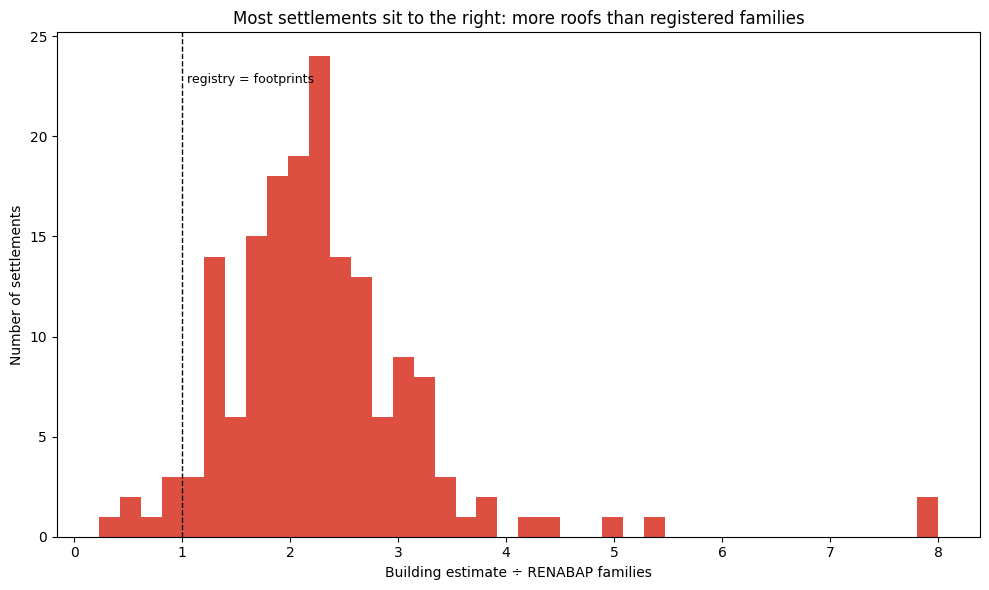

In [ ]:
# | label: fig-error
# | fig-cap: "Ratio of building-based family estimate to RENABAP families, by settlement"
# | code-fold: true
# | code-summary: "Show plot code"

valid = est[est["familias_aproximadas"] > 0].copy()
valid["ratio"] = (
    valid["building_count"] * FAMILIES_PER_DWELLING / valid["familias_aproximadas"]
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(valid["ratio"].clip(upper=8), bins=40, color="#d7301f", alpha=0.85)
ax.axvline(1.0, color="black", linestyle="--", linewidth=1)
ax.text(1.05, ax.get_ylim()[1] * 0.9, "registry = footprints", fontsize=9)
ax.set_xlabel("Building estimate \u00f7 RENABAP families")
ax.set_ylabel("Number of settlements")
ax.set_title("Most settlements sit to the right: more roofs than registered families")
plt.tight_layout()
plt.show()

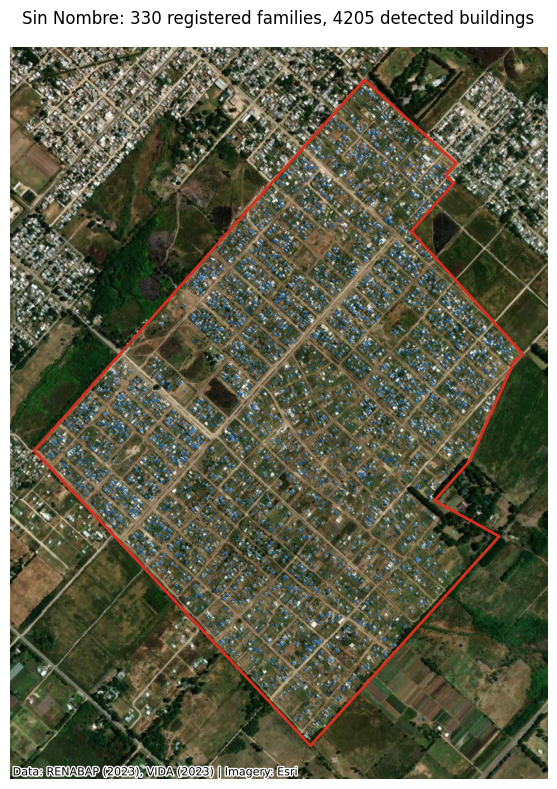

In [ ]:
# | label: fig-example
# | fig-cap: "A settlement where detected buildings far exceed the registered family count"
# | code-fold: true
# | code-summary: "Show plot code"

# Pick the settlement with the largest absolute gap
est["gap"] = est["building_count"] * FAMILIES_PER_DWELLING - est["familias_aproximadas"]
example_id = est.sort_values("gap", ascending=False)["id_renabap"].iloc[0]
example = barrios[barrios["id_renabap"] == example_id].to_crs(WEB_MERCATOR_CRS)
example_row = est[est["id_renabap"] == example_id].iloc[0]
example_buildings = gpd.clip(
    buildings.to_crs(WEB_MERCATOR_CRS), example.to_crs(WEB_MERCATOR_CRS)
)

fig, ax = plt.subplots(figsize=DEFAULT_FIGSIZE)
example.plot(ax=ax, facecolor="none", edgecolor="#d7301f", linewidth=2)
example_buildings.plot(ax=ax, facecolor="#08519c", edgecolor="none", alpha=0.7)
cx.add_basemap(
    ax,
    crs=WEB_MERCATOR_CRS,
    source=cx.providers.Esri.WorldImagery,
    attribution="Data: RENABAP (2023), VIDA (2023) | Imagery: Esri",
)
ax.set_title(
    f"{example_row['nombre_barrio']}: "
    f"{int(example_row['familias_aproximadas'])} registered families, "
    f"{int(example_row['building_count'])} detected buildings"
)
ax.axis("off")
plt.tight_layout()
plt.show()

## Why keep both sources

It would be tempting to throw out the registry and trust the footprints. That
would be a mistake, because each source is blind to something the other sees.

Footprints miss **vertical density**. A computer-vision model sees one roof and
counts one building, whether a single family lives under it or six families live
stacked in a consolidated three-story dwelling. In older, denser settlements,
especially the *villas* of the urban core, the registry's family count can
exceed the footprint count for exactly this reason.

The registry misses **horizontal sprawl**. Where settlements grow outward in
single-story dwellings faster than surveyors can re-enumerate, the footprints
race ahead of the registered family count. This is the dominant pattern in La
Plata, and in most of Argentina outside the capital.

Keeping the higher of the two estimates per settlement lets each source cover
the other's blind spot. The result is a population layer that is both more
accurate and more complete than either input.

::: {.callout-important}
## The national picture, and the census

The pattern in La Plata is not local. The
[Barrios Visibles working paper](https://nlebovits.github.io/posts/writing/informal-settlements-argentina/)
[@lebovits_barrios_visibles] runs this method across all 6,467 RENABAP
settlements and finds the registry undercounts households by roughly 83%,
implying between 6.3 and 7.6 million residents nationally where the registry
implies far fewer. A
[follow-up analysis](https://nlebovits.github.io/posts/writing/barrios-visibles-part-ii/)
compares footprints against the 2022 national census [@indec_bases_datos] rather
than the registry, and finds the census captures only about half the population
that the footprints imply, even after correcting for boundary artifacts.

The point is not that any one source is broken. It is that in informal
settlements, where enumeration is hardest and the stakes are highest, no single
official dataset should be trusted on its own. Open building footprints are a
cheap, reproducible second opinion. Whatever the gap looks like in Argentina,
which maintains a relatively strong statistical system, it is likely worse in
places with thinner capacity.
:::

## A corrected exposure layer

The deliverable is a per-settlement table that carries both the official count
and the building-based estimate. This is the population layer you would carry
into a hazard analysis: instead of asking how many *registered* families sit in
a flood zone, you can ask how many families the buildings actually suggest are
there.

In [ ]:
# | label: tbl-corrected
# | code-fold: true
# | code-summary: "Show table code"

summary = (
    est[
        [
            "nombre_barrio",
            "familias_aproximadas",
            "building_count",
            "estimated_families",
        ]
    ]
    .rename(
        columns={
            "nombre_barrio": "Settlement",
            "familias_aproximadas": "RENABAP families",
            "building_count": "Footprints",
            "estimated_families": "Estimated families",
        }
    )
    .sort_values("Estimated families", ascending=False)
    .head(15)
    .round(0)
)
summary

,Settlement,RENABAP families,Footprints,Estimated families
98,Sin Nombre,330,4205,4626.0
140,Puente de Fierro,1551,3238,3562.0
61,El Retiro,902,2607,2868.0
16,Las Rosas,1034,2082,2290.0
157,Villa Aburridita,805,1942,2136.0
137,La Esperanza,954,1937,2131.0
35,El Futuro,1024,1865,2052.0
148,Villa Montoro,1100,1751,1926.0
19,Barrio Nuevo,334,1624,1786.0
153,Villa Montoro,567,1292,1421.0


From here the workflow rejoins the rest of the book. The
[Pergamino](pergamino.ipynb) and [Esperanza](esperanza.ipynb) cookbooks show how
to overlay an exposure layer like this one on a hazard surface to find who, and
how many, are at risk. The difference is that the population layer you feed them
is now built to see the people the official record misses.

## Limitations

Building footprints are a supplement, not ground truth. A few cautions apply.

RENABAP boundaries are fixed at the time of survey, while settlements move and
grow; a footprint near a boundary may or may not belong to the settlement. The
registry only records settlements in localities above 2,000 inhabitants, so the
smallest and most rural informal housing is missing from both the registry and
this analysis. Footprint detection itself degrades where roofs are small, dark,
or packed tightly together, which describes many informal settlements, so the
building count is more likely to be low than high. And a footprint says nothing
about building height, which is why the vertical-density correction relies on
the registry rather than the imagery.

None of these displaces the central finding. Two flawed sources, combined, give
a far better picture of where vulnerable populations live than either source
used alone.